In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

print('Please select file to upload:')
uploaded = files.upload()


Please select file to upload:


In [ ]:
df1 = pd.read_csv("historical_data.csv")
df2 = pd.read_csv("fear_greed_index.csv")

# Convert 'Timestamp IST' in df1 to datetime and extract date
df1['trade_date'] = pd.to_datetime(df1['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

# Convert 'date' in df2 to datetime
df2['date'] = pd.to_datetime(df2['date']).dt.date

# Merge the two dataframes on the date columns
df = pd.merge(df1, df2, left_on='trade_date', right_on='date', how='inner')

# Drop redundant date columns if desired
df = df.drop(columns=['trade_date', 'date', 'timestamp', 'value'])


In [ ]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,Extreme Greed


In [ ]:
df.shape

(211218, 17)

In [ ]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'classification'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211218 non-null  object 
 1   Coin              211218 non-null  object 
 2   Execution Price   211218 non-null  float64
 3   Size Tokens       211218 non-null  float64
 4   Size USD          211218 non-null  float64
 5   Side              211218 non-null  object 
 6   Timestamp IST     211218 non-null  object 
 7   Start Position    211218 non-null  float64
 8   Direction         211218 non-null  object 
 9   Closed PnL        211218 non-null  float64
 10  Transaction Hash  211218 non-null  object 
 11  Order ID          211218 non-null  int64  
 12  Crossed           211218 non-null  bool   
 13  Fee               211218 non-null  float64
 14  Trade ID          211218 non-null  float64
 15  Timestamp         211218 non-null  float64
 16  classification    21

In [ ]:
df.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211218.000000,2.112180e+05,2.112180e+05,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05
mean,11415.047529,4.623341e+03,5.639192e+03,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12
std,29448.010305,1.042744e+05,3.657557e+04,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.858550,2.940000e+00,1.937900e+02,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970200e+02,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12
75%,101.895000,1.878900e+02,2.058878e+03,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [ ]:
df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


/tmp/ipykernel_19422/3097678903.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


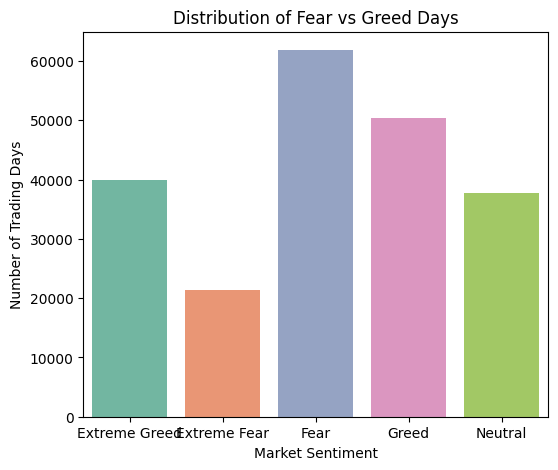

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [ ]:
# Distribution of Fear vs Greed Days
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='classification',
    palette='Set2'
)

plt.title("Distribution of Fear vs Greed Days")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trading Days")

plt.show()

# Count of each sentiment
print(df['classification'].value_counts())

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


/tmp/ipykernel_19422/2464861814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


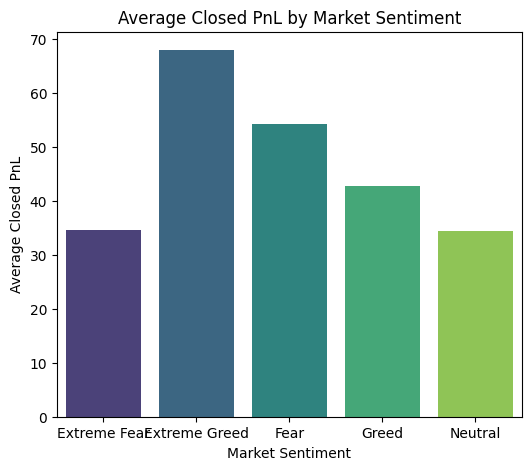

In [ ]:

# Avearge Pnl During Fear and Greed
avg_pnl = df.groupby('classification')['Closed PnL'].mean().reset_index()

print(avg_pnl)

plt.figure(figsize=(6,5))

sns.barplot(
    data=avg_pnl,
    x='classification',
    y='Closed PnL',
    palette='viridis'
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

Profit_Flag          Loss        Win
classification                      
Extreme Fear    62.939252  37.060748
Extreme Greed   53.505701  46.494299
Fear            57.923250  42.076750
Greed           61.517206  38.482794
Neutral         60.300907  39.699093


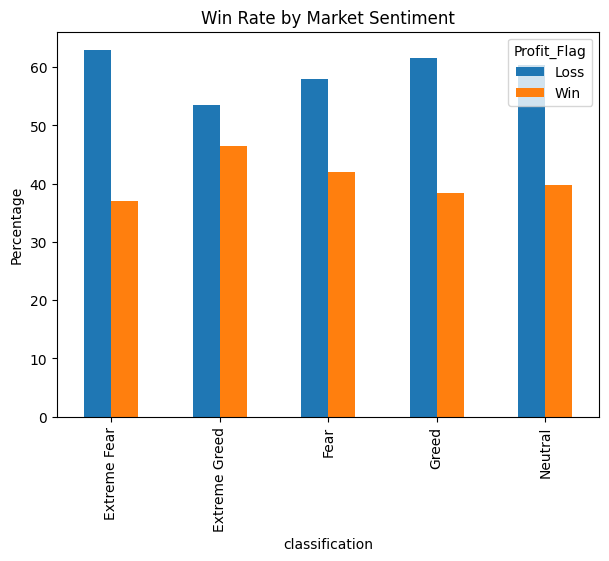

In [ ]:
# Win rate by sentiment
# Create Profit/Loss Flag
df['Profit_Flag'] = df['Closed PnL'].apply(
    lambda x: 'Win' if x > 0 else 'Loss'
)

win_rate = pd.crosstab(
    df['classification'],
    df['Profit_Flag'],
    normalize='index'
) * 100

print(win_rate)

win_rate.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Percentage")
plt.show()

  classification  Size Tokens
0   Extreme Fear  1675.893319
1  Extreme Greed  8832.415746
2           Fear  2992.641845
3          Greed  4715.327756
4        Neutral  4383.368714


/tmp/ipykernel_19422/111457339.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


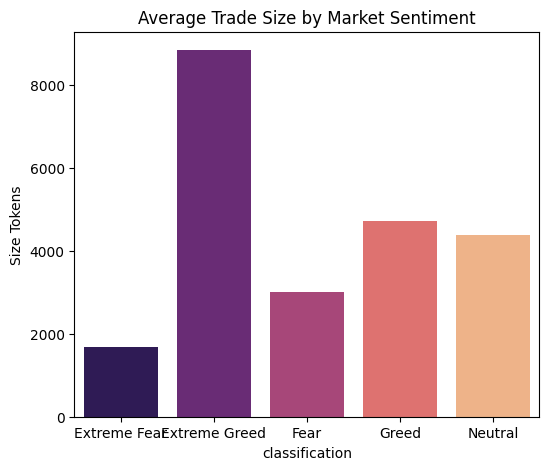

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Trend by sentiment
trade_size = df.groupby('classification')['Size Tokens'].mean().reset_index()

print(trade_size)

plt.figure(figsize=(6,5))

sns.barplot(
    data=trade_size,
    x='classification',
    y='Size Tokens',
    palette='magma'
)

plt.title("Average Trade Size by Market Sentiment")

plt.show()

   Side   count       mean           sum
0   BUY  102690  35.693245  3.665339e+06
1  SELL  108528  60.713803  6.589148e+06


/tmp/ipykernel_19422/2962882299.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


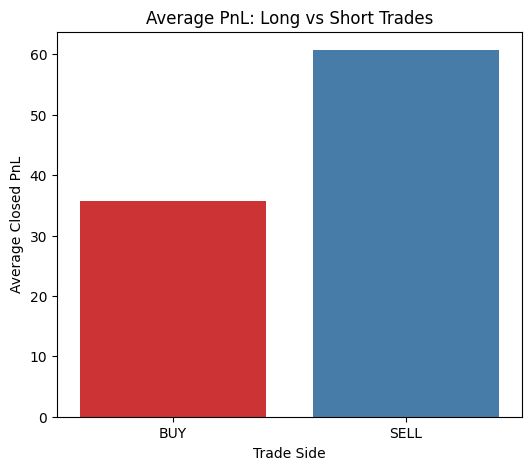

In [ ]:
# Long vs Short Performance
long_short = df.groupby('Side')['Closed PnL'].agg(
    ['count','mean','sum']
).reset_index()

print(long_short)

plt.figure(figsize=(6,5))

sns.barplot(
    data=long_short,
    x='Side',
    y='mean',
    palette='Set1'
)

plt.title("Average PnL: Long vs Short Trades")
plt.xlabel("Trade Side")
plt.ylabel("Average Closed PnL")

plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


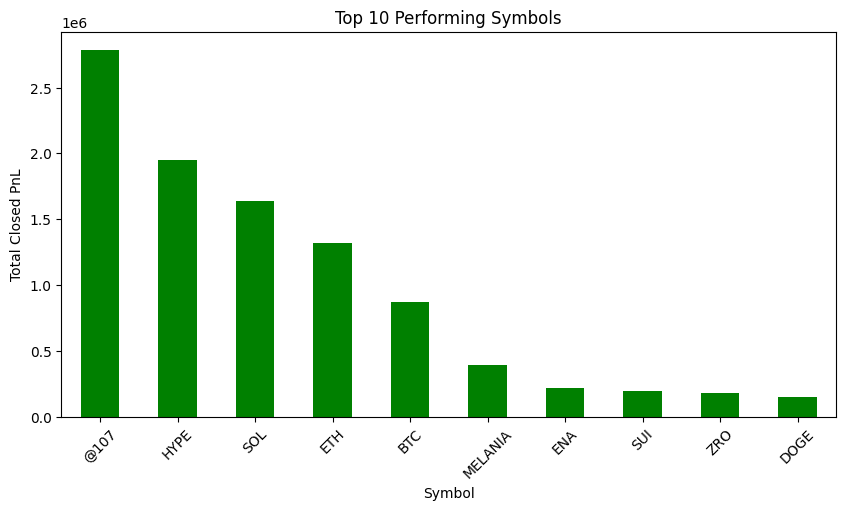

In [ ]:
# Top Performing Symbols
top_symbols = df.groupby('Coin')['Closed PnL'].sum()

top_symbols = top_symbols.sort_values(ascending=False).head(10)

print(top_symbols)

plt.figure(figsize=(10,5))

top_symbols.plot(
    kind='bar',
    color='green'
)

plt.title("Top 10 Performing Symbols")
plt.xlabel("Symbol")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

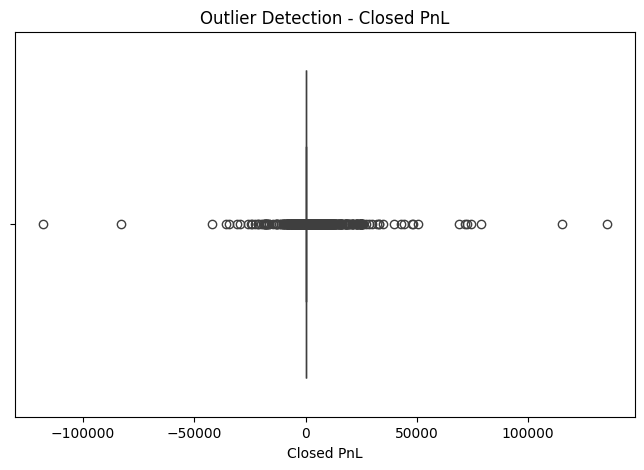

In [ ]:
# Boxplot for outline detection
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Closed PnL'])

plt.title("Outlier Detection - Closed PnL")

plt.show()

In [ ]:
#Detect outlier Using IQR Method
Q1 = df['Closed PnL'].quantile(0.25)
Q3 = df['Closed PnL'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Closed PnL'] < lower) |
    (df['Closed PnL'] > upper)
]

print("Number of Outliers:", len(outliers))
outliers.head()

Number of Outliers: 48942


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,classification,Profit_Flag
44,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0570,2446.39,22156.95,SELL,03-12-2024 14:39,10000.498600,Sell,3008.231185,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,7.754933,5.190000e+14,1.730000e+12,Extreme Greed,Win
45,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0570,25.00,226.43,SELL,03-12-2024 14:39,7554.108602,Sell,30.741534,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.079248,3.350000e+14,1.730000e+12,Extreme Greed,Win
46,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0480,33.40,302.20,SELL,03-12-2024 14:39,7529.108602,Sell,40.770089,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.105771,5.140000e+14,1.730000e+12,Extreme Greed,Win
47,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0464,200.00,1809.28,SELL,03-12-2024 14:39,7495.708602,Sell,243.812267,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.633248,9.540000e+14,1.730000e+12,Extreme Greed,Win
48,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0424,209.26,1892.21,SELL,03-12-2024 14:39,7295.708602,Sell,254.263735,0x7b57a76296641058064004184ed84d01d0005daded34...,52200758791,True,0.662274,7.470000e+14,1.730000e+12,Extreme Greed,Win


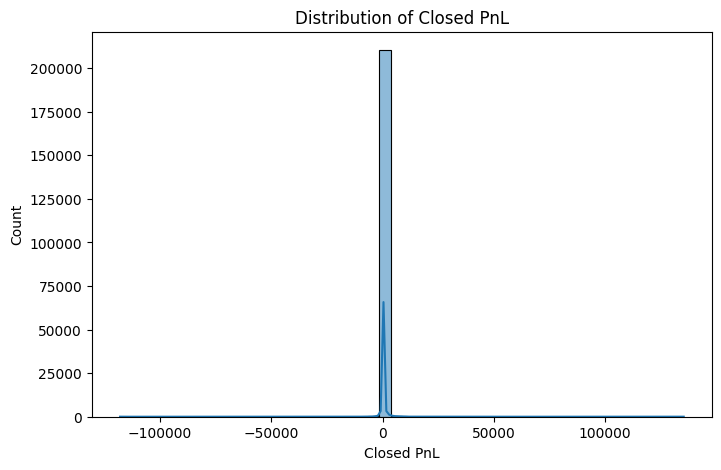

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Closed PnL'],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")

plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


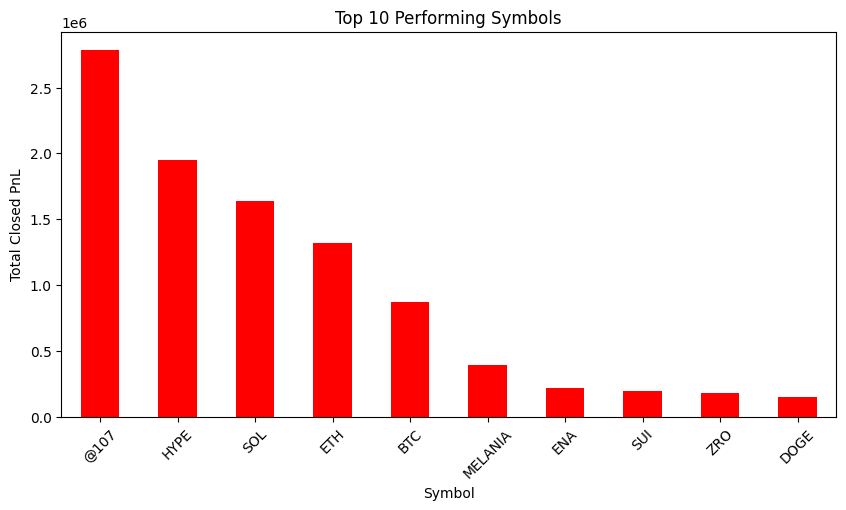

In [ ]:
# Based on total profit
top_symbols = df.groupby('Coin')['Closed PnL'].sum()

top_symbols = top_symbols.sort_values(ascending=False).head(10)

print(top_symbols)

plt.figure(figsize=(10,5))

top_symbols.plot(
    kind='bar',
    color='red'
)

plt.title("Top 10 Performing Symbols")
plt.xlabel("Symbol")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

In [ ]:
import pandas as pd

# EDA Summary Table
eda_summary = df.groupby('classification').agg(
    Total_Trades=('Closed PnL','count'),
    Average_PnL=('Closed PnL','mean'),
    Total_PnL=('Closed PnL','sum'),
    Avg_Trade_Size=('Size Tokens','mean')
)

display(eda_summary)

,Total_Trades,Average_PnL,Total_PnL,Avg_Trade_Size
classification,,,,
Extreme Fear,21400,34.537862,7.391102e+05,1675.893319
Extreme Greed,39992,67.892861,2.715171e+06,8832.415746
Fear,61837,54.290400,3.357155e+06,2992.641845
Greed,50303,42.743559,2.150129e+06,4715.327756
Neutral,37686,34.307718,1.292921e+06,4383.368714
